(sec-eoa2-top)=

<div align="center">
    <h1>Elements of Data Analysis - Clustering</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <a href="https://colab.research.google.com/github/SECQUOIA/PU_CHE597_DSinChemE/blob/main/21-EoA_Clustering/Elements_of_Data_Analysis.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

# Elements of Data Analysis - Clustering
## Table of Contents
- [Clustering Operating Regimes in the Dow Dataset](#sec-eoa2-main)
  - [Overview of the plant operation](#sec-eoa2-overview)
  - [Summary of Variables](#sec-eoa2-vars)
  - [Reading and cleaning the data](#sec-eoa2-read)
  - [Why scaling matters](#sec-eoa2-scale)
  - [PCA view of the full record](#sec-eoa2-pca)
  - [First pass: isolate the shutdown-like regime](#sec-eoa2-pass1)
  - [Second pass: cluster routine operation](#sec-eoa2-pass2)
  - [Interpreting the operating modes](#sec-eoa2-interpret)
  - [Alternative method: Ward agglomerative clustering](#sec-eoa2-alt)
  - [Connection to HW8](#sec-eoa2-hw8)
- [References](#sec-eoa2-refs)

In [1]:
# Detect whether the notebook is running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

<b>If you are using Google Colab, keep this notebook and its supporting files (`ImpurityDataset_Training.xlsx`, `dow.png`, and `dow_variables.png`) in the same folder. If you use Google Drive, adapt the next cell to your own folder layout.</b>

In [2]:
# Optional Google Drive mount
USE_GOOGLE_DRIVE = False
if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/My\ Drive/CHE597/Lectures/21-EoA_Clustering

(sec-eoa2-main)=
## Clustering Operating Regimes in the Dow Dataset
This notebook revisits the Dow impurity dataset, but now with a different goal from the earlier outlier/PCA lecture. Here we use clustering to identify **operating regimes** in a chemical process: broad patterns in pressures, temperatures, flows, and concentration-related variables that tend to move together.

A useful way to think about this workflow is:
1. Clean the record enough that distance-based methods are meaningful.
2. Standardize the sensor variables so clustering is not dominated by units.
3. Use PCA for visualization and dimensionality reduction.
4. Use clustering to separate shutdown-like behavior from routine operation.
5. Interpret the clusters in process terms, then look at impurity only **after** the clustering step.

(sec-eoa2-overview)=
### Overview of the plant operation

![dow.png](dow.png)

(sec-eoa2-vars)=
### Summary of Variables
The table below defines the variables in the dataset (thanks to Leo Chiang and Dow Chemical Co. for providing the data). In this lecture we cluster only the physical sensor variables `x1`-`x40`. We leave `y:Impurity` for post-hoc interpretation rather than using it to define the clusters.

![dow_variables.png](dow_variables.png)

This choice is important. If you cluster on impurity itself, or on variables that are nearly a proxy for impurity, you stop learning about operating modes and instead start rediscovering the target. For process understanding, the sensor state should drive the clustering.

In [3]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

plt.style.use('default')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 32509814


def short_name(col):
    return re.sub(r'^x\d+:\s*', '', col)


def top_shift_table(X_scaled, labels, columns, top_n=6):
    shifts = pd.DataFrame(X_scaled, columns=columns).assign(cluster=labels).groupby('cluster').mean()
    rows = []
    for cluster in sorted(shifts.index):
        ranked = shifts.loc[cluster].abs().sort_values(ascending=False).head(top_n).index
        for rank, col in enumerate(ranked, start=1):
            rows.append(
                {
                    'cluster': cluster,
                    'rank': rank,
                    'feature': col,
                    'feature_short': short_name(col),
                    'shift_z': shifts.loc[cluster, col],
                }
            )
    return pd.DataFrame(rows)


def remap_by_impurity(labels, impurity):
    order = (
        pd.DataFrame({'label': labels, 'impurity': impurity})
        .groupby('label')['impurity']
        .mean()
        .sort_values()
        .index
    )
    mapping = {old: new for new, old in enumerate(order)}
    new_labels = np.array([mapping[label] for label in labels])
    return new_labels, mapping

(sec-eoa2-read)=
### Reading and cleaning the data
We will work from the raw training spreadsheet in this directory. As in the earlier Dow notebook, we coerce the non-numeric `x37` entries to numeric and then drop rows with missing values. That is not the only possible cleaning policy, but it is simple and makes the clustering example reproducible.

The dataset also contains `Avg_*` and ratio variables, but for this lecture we keep the clustering problem focused on the 40 sensor variables `x1`-`x40`.

In [4]:
data_file = Path('ImpurityDataset_Training.xlsx')
if not data_file.exists():
    raise FileNotFoundError(f'Missing expected data file: {data_file.resolve()}')

dow = pd.read_excel(data_file)
dow['x37: Feed Column Tails Flow to Primary Column'] = pd.to_numeric(
    dow['x37: Feed Column Tails Flow to Primary Column'], errors='coerce'
)

rows_before = len(dow)
dow = dow.dropna().copy()
rows_after = len(dow)

sensor_cols = [col for col in dow.columns if re.match(r'^x\d+:', col)]
X_full = dow[sensor_cols].copy()
y_imp = dow['y:Impurity'].to_numpy()

print(f'Rows before cleaning: {rows_before}')
print(f'Rows after cleaning:  {rows_after}')
print(f'Rows removed:         {rows_before - rows_after}')
print(f'Number of sensor variables used for clustering: {len(sensor_cols)}')
print(f'Impurity range (raw units): {dow["y:Impurity"].min():.3f} to {dow["y:Impurity"].max():.3f}')

display(dow[['Date', 'y:Impurity'] + sensor_cols[:5]].head())

Rows before cleaning: 10703
Rows after cleaning:  10297
Rows removed:         406
Number of sensor variables used for clustering: 40
Impurity range (raw units): 0.000 to 14.120


,Date,y:Impurity,x1:Primary Column Reflux Flow,x2:Primary Column Tails Flow,x3:Input to Primary Column Bed 3 Flow,x4:Input to Primary Column Bed 2 Flow,x5:Primary Column Feed Flow from Feed Column
0,2015-12-01 00:00:00,1.77833,327.813,45.7920,2095.06,2156.01,98.5005
1,2015-12-01 01:00:00,1.76964,322.970,46.1643,2101.00,2182.90,98.0014
2,2015-12-01 02:00:00,1.76095,319.674,45.9927,2102.96,2151.39,98.8229
3,2015-12-01 03:00:00,1.75226,327.223,46.0960,2101.37,2172.14,98.7733
4,2015-12-01 04:00:00,1.74357,331.177,45.8493,2114.06,2157.77,99.3231


(sec-eoa2-scale)=
### Why scaling matters
K-means and PCA are both sensitive to feature scale. A temperature measured over a large numerical range can dominate a pressure or flow variable simply because its units are bigger, not because it is more informative.

That is why we standardize the sensor block before clustering. In standardized coordinates, a shift of `+1` means “one standard deviation above the global mean”, regardless of the original units. This is also the scale we will use later when we interpret cluster centers.

,smallest-feature,smallest-std,largest-feature,largest-std
0,x37: Feed Column Tails Flow to Primary Column,0.001,x3:Input to Primary Column Bed 3 Flow,571.323
1,x35: Secondary Column Tails Concentration,0.026,x4:Input to Primary Column Bed 2 Flow,503.672
2,x22: Secondary Column Base Concentration,0.148,x23: Flow from Input to Secondary Column,452.498
3,x25: Secondary Column Tray DP,1.314,x1:Primary Column Reflux Flow,75.652
4,x39: Feed Column Steam Flow,1.789,x6:Primary Column Make Flow,28.087


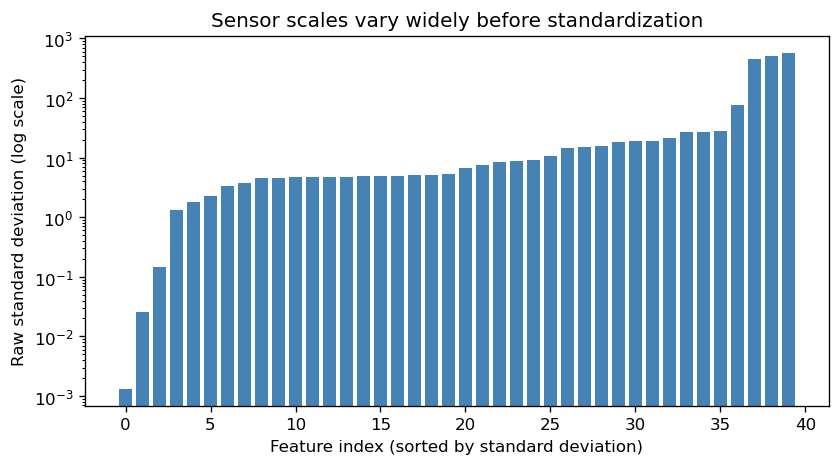

Mean of first five standardized features: [ 0. -0. -0.  0. -0.]
Std of first five standardized features:  [1. 1. 1. 1. 1.]


In [5]:
feature_std = X_full.std().sort_values()
scale_table = pd.DataFrame(
    {
        'smallest-feature': feature_std.head(5).index,
        'smallest-std': feature_std.head(5).values,
        'largest-feature': feature_std.tail(5).sort_values(ascending=False).index,
        'largest-std': feature_std.tail(5).sort_values(ascending=False).values,
    }
)
display(scale_table.round(3))

plt.figure(figsize=(8, 4))
plt.bar(range(len(feature_std)), feature_std.values, color='steelblue')
plt.yscale('log')
plt.xlabel('Feature index (sorted by standard deviation)')
plt.ylabel('Raw standard deviation (log scale)')
plt.title('Sensor scales vary widely before standardization')
plt.show()

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)
print('Mean of first five standardized features:', np.round(X_full_scaled[:, :5].mean(axis=0), 3))
print('Std of first five standardized features: ', np.round(X_full_scaled[:, :5].std(axis=0), 3))

(sec-eoa2-pca)=
### PCA view of the full record
Before fitting a cluster model, it helps to look at the global geometry of the dataset. PCA gives a lower-dimensional view of the 40-dimensional sensor space while preserving as much variance as possible.

We will use the standardized sensor block for PCA. The impurity values below are shown only as an overlay to help interpret the structure after the fact.

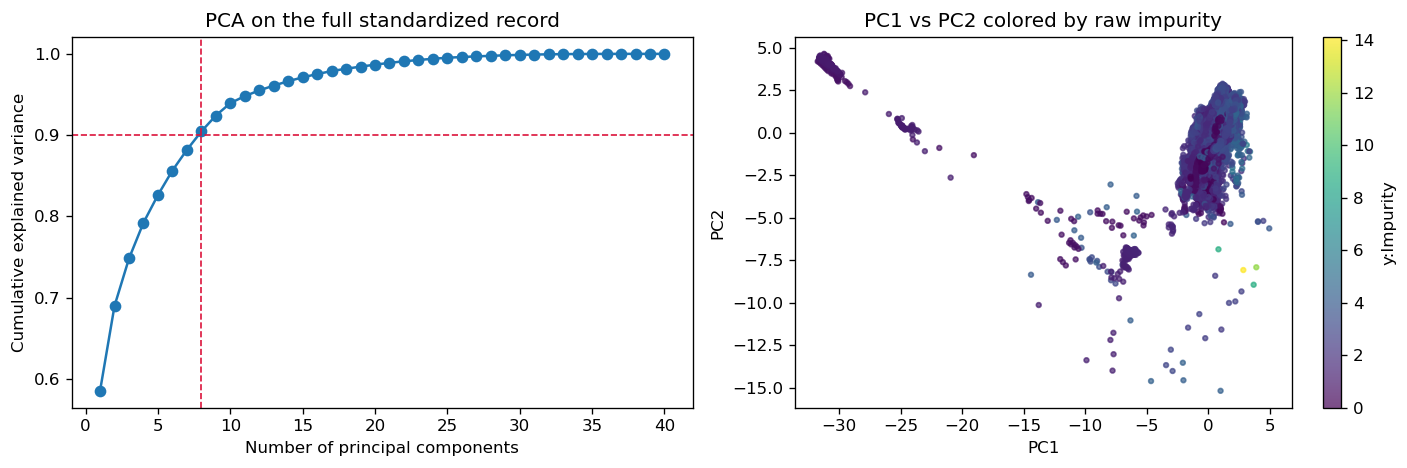

Principal components required for 90% variance: 8
Explained variance ratios of the first 6 PCs: [0.5851 0.1046 0.0583 0.0441 0.0341 0.0302]


In [6]:
pca_full = PCA()
X_full_pca = pca_full.fit_transform(X_full_scaled)
full_cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90_full = int(np.searchsorted(full_cumvar, 0.90) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, len(full_cumvar) + 1), full_cumvar, marker='o')
axes[0].axhline(0.90, color='crimson', linestyle='--', linewidth=1)
axes[0].axvline(n90_full, color='crimson', linestyle='--', linewidth=1)
axes[0].set_xlabel('Number of principal components')
axes[0].set_ylabel('Cumulative explained variance')
axes[0].set_title('PCA on the full standardized record')

scatter = axes[1].scatter(
    X_full_pca[:, 0],
    X_full_pca[:, 1],
    c=dow['y:Impurity'],
    s=8,
    cmap='viridis',
    alpha=0.7,
)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PC1 vs PC2 colored by raw impurity')
fig.colorbar(scatter, ax=axes[1], label='y:Impurity')
plt.tight_layout()
plt.show()

print(f'Principal components required for 90% variance: {n90_full}')
print('Explained variance ratios of the first 6 PCs:', np.round(pca_full.explained_variance_ratio_[:6], 4))

(sec-eoa2-pass1)=
### First pass: isolate the shutdown-like regime
If we cluster the full record directly, the most obvious structure is a compact regime that is far from the rest of the data. In process terms, this is useful: one of the first jobs of clustering is often to identify whether the record contains a special operating state such as startup, shutdown, or severe throughput reduction.

We start with `k=2` on the PCA scores of the full dataset. The smaller cluster is not automatically “bad” or “wrong”, but it is clearly distinct enough that routine operating-mode analysis should treat it separately.

,count,impurity_mean,impurity_min,impurity_max
cluster,,,,
0,10055,2.749,0.000,14.120
1,242,0.919,0.568,1.211


,rank,feature_short,shift_z
8,1,Primary Column Bed 2 Temperature,-6.15
9,2,Primary Column Bed 1 Temperature,-6.13
10,3,Secondary Column Tails Temperature,-6.13
11,4,Secondary Column Base Concentration,6.11
12,5,Primary Column Bed 3 Temperature,-6.03
13,6,Primary Column Bed 4 Temperature,-6.02
14,7,Primary Column Base Level,-5.83
15,8,Primary Column Tails Flow,-5.76


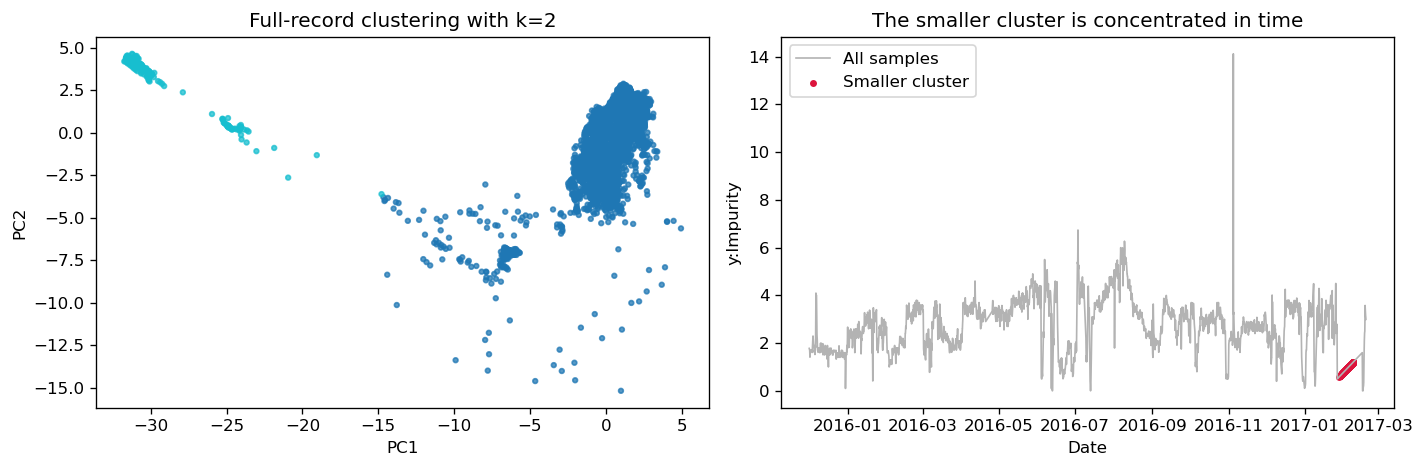

Smaller cluster size: 242 samples
Smaller cluster date span: 2017-01-28 06:00:00 to 2017-02-08 23:00:00


In [7]:
kmeans_full = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
full_labels = kmeans_full.fit_predict(X_full_pca[:, :n90_full])
full_counts = pd.Series(full_labels).value_counts().sort_index()
off_label = int(full_counts.idxmin())

full_summary = (
    dow.assign(cluster=full_labels)
    .groupby('cluster')
    .agg(
        count=('y:Impurity', 'size'),
        impurity_mean=('y:Impurity', 'mean'),
        impurity_min=('y:Impurity', 'min'),
        impurity_max=('y:Impurity', 'max'),
    )
)
display(full_summary.round(3))

off_dates = dow.loc[full_labels == off_label, 'Date']
off_shifts = top_shift_table(X_full_scaled, full_labels, sensor_cols, top_n=8)
off_shifts = off_shifts[off_shifts['cluster'] == off_label].copy()
display(off_shifts[['rank', 'feature_short', 'shift_z']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_full_pca[:, 0], X_full_pca[:, 1], c=full_labels, cmap='tab10', s=8, alpha=0.75)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Full-record clustering with k=2')

axes[1].plot(dow['Date'], dow['y:Impurity'], color='0.7', linewidth=1, label='All samples')
axes[1].scatter(
    dow.loc[full_labels == off_label, 'Date'],
    dow.loc[full_labels == off_label, 'y:Impurity'],
    color='crimson',
    s=10,
    label='Smaller cluster',
)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('y:Impurity')
axes[1].set_title('The smaller cluster is concentrated in time')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'Smaller cluster size: {full_counts.loc[off_label]} samples')
print(f'Smaller cluster date span: {off_dates.min()} to {off_dates.max()}')

The smaller full-record cluster is characterized by very large negative shifts in bed and tails temperatures, base level, and tails flow. That makes a shutdown-like or severely reduced-throughput interpretation reasonable.

For routine operating-mode discovery, it makes sense to set that regime aside temporarily and ask a second question: **within normal operation, are there still distinct modes?**

(sec-eoa2-pass2)=
### Second pass: cluster routine operation
Now we remove the shutdown-like cluster and refit the clustering workflow on the remaining samples. This is a common industrial pattern: first isolate special states, then characterize the routine envelope.

Here we compare candidate values of `k` using two diagnostics:
- **Silhouette score**: higher is better; it measures how well samples sit within their assigned cluster versus neighboring clusters.
- **Davies-Bouldin index (DBI)**: lower is better; it penalizes clusters that are diffuse or not well separated.

Neither metric should be followed blindly. If a larger `k` only creates tiny transient clusters, the score may improve while the process story gets worse.

,k,silhouette,davies_bouldin,smallest_cluster,largest_cluster
0,2,0.282,1.582,4374,5681
1,3,0.295,1.376,208,5232
2,4,0.300,1.102,18,5233
3,5,0.342,1.038,18,4777
4,6,0.344,1.042,18,4765


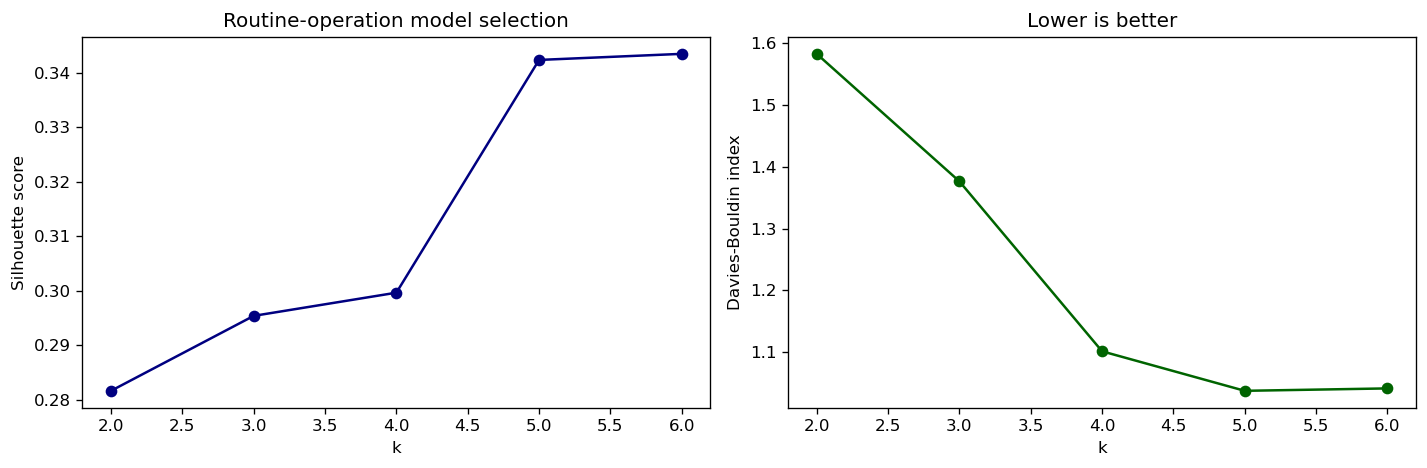

Routine-operation PCs required for 90% variance: 13


In [8]:
routine = dow.loc[full_labels != off_label].copy()
X_routine = routine[sensor_cols].copy()

scaler_routine = StandardScaler()
X_routine_scaled = scaler_routine.fit_transform(X_routine)

pca_routine = PCA()
X_routine_pca = pca_routine.fit_transform(X_routine_scaled)
routine_cumvar = np.cumsum(pca_routine.explained_variance_ratio_)
n90_routine = int(np.searchsorted(routine_cumvar, 0.90) + 1)

rows = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_routine_pca[:, :n90_routine])
    counts = np.bincount(labels)
    rows.append(
        {
            'k': k,
            'silhouette': silhouette_score(X_routine_pca[:, :n90_routine], labels),
            'davies_bouldin': davies_bouldin_score(X_routine_pca[:, :n90_routine], labels),
            'smallest_cluster': counts.min(),
            'largest_cluster': counts.max(),
        }
    )

k_df = pd.DataFrame(rows)
display(k_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_df['k'], k_df['silhouette'], marker='o', color='navy')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette score')
axes[0].set_title('Routine-operation model selection')

axes[1].plot(k_df['k'], k_df['davies_bouldin'], marker='o', color='darkgreen')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin index')
axes[1].set_title('Lower is better')
plt.tight_layout()
plt.show()

print(f'Routine-operation PCs required for 90% variance: {n90_routine}')

For this dataset, `k=4` and `k=5` improve the metrics only by peeling off very small clusters. For lecture purposes, `k=3` is a more defensible choice: it preserves two broad routine modes plus one short-duration transient regime that is chemically interpretable.

That tradeoff is worth seeing explicitly. Clustering metrics are useful diagnostics, but process judgment still matters.

(sec-eoa2-interpret)=
### Interpreting the operating modes
We now fit the routine-operation model with `k=3`. After fitting, we reorder the labels by increasing mean impurity only to make the plots easier to read. The clustering itself still uses only sensor data.

To interpret the clusters, we look at two things:
1. Their time distribution and impurity overlay.
2. Their most shifted sensor variables in standardized units.

A shift of `-5` in scaled units means the cluster center is five standard deviations below the global routine-operation mean for that variable, which is an extremely strong process signature.

,count,impurity_mean,impurity_q90,impurity_max,first_date,last_date
cluster,,,,,,
0,208,1.642,3.601,4.402,2016-07-08 00:00:00,2017-02-14 06:00:00
1,4615,2.183,3.200,14.120,2015-12-01 00:00:00,2017-02-17 06:00:00
2,5232,3.292,4.400,6.740,2015-12-15 15:00:00,2017-02-18 23:00:00


,cluster,rank,feature_short,shift_z
0,0,1,Feed Column Steam Flow,-6.61
1,0,2,Feed Column Tails Flow,-5.18
2,0,3,Primary Column Feed Flow from Feed Column,-5.15
3,0,4,Feed Column Recycle Flow,-5.12
4,0,5,Feed Column Calculated DP,-4.74
5,0,6,Primary Column Make Flow,-4.65
6,1,1,Secondary Column Head Pressure,-0.74
7,1,2,Secondary Column Base Pressure,-0.74
8,1,3,Primary Column Base Pressure,-0.74
9,1,4,Primary Column Bed 1 Temperature,-0.68


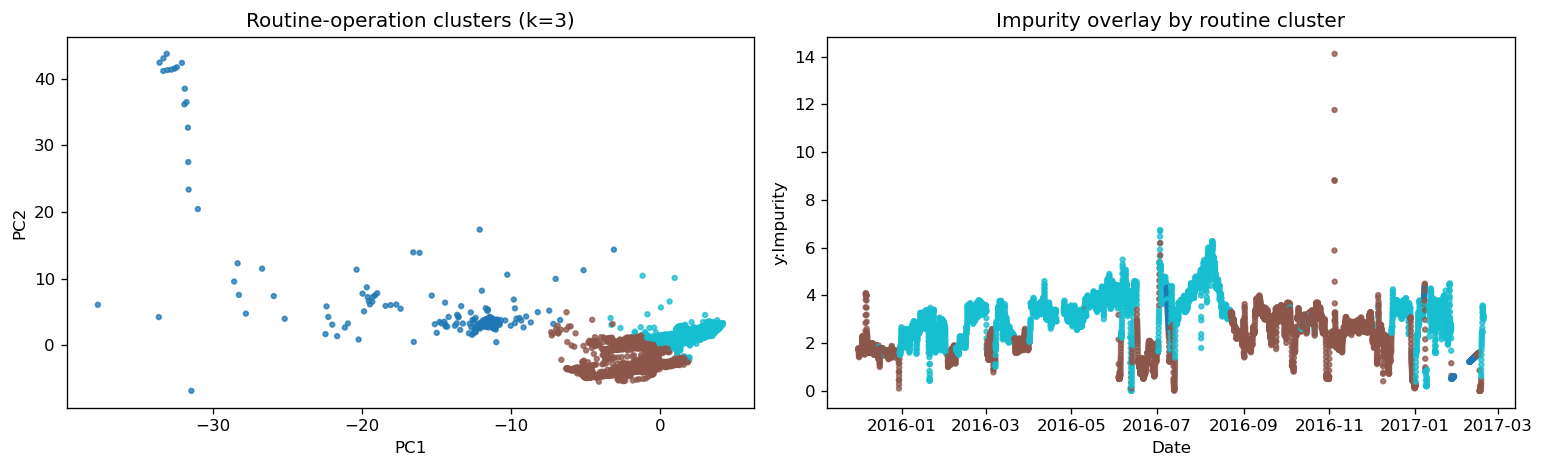

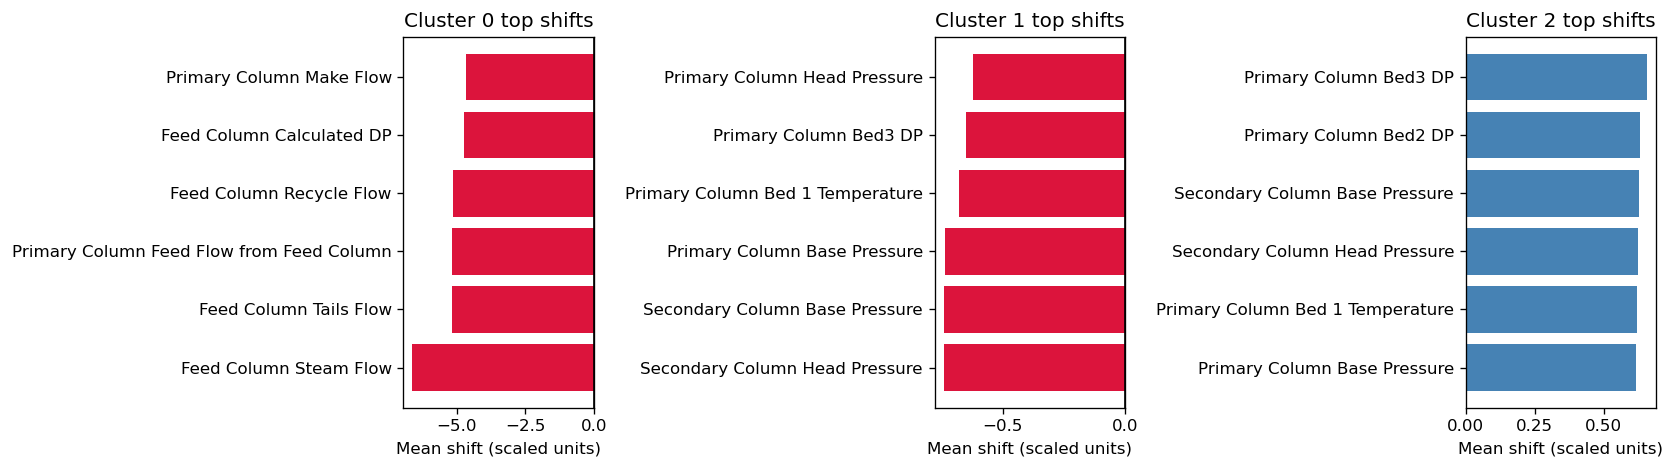

In [9]:
kmeans_routine = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
routine_labels_raw = kmeans_routine.fit_predict(X_routine_pca[:, :n90_routine])
routine_labels, label_map = remap_by_impurity(routine_labels_raw, routine['y:Impurity'].to_numpy())

routine = routine.copy()
routine['cluster'] = routine_labels

cluster_summary = (
    routine.groupby('cluster')
    .agg(
        count=('y:Impurity', 'size'),
        impurity_mean=('y:Impurity', 'mean'),
        impurity_q90=('y:Impurity', lambda s: s.quantile(0.9)),
        impurity_max=('y:Impurity', 'max'),
        first_date=('Date', 'min'),
        last_date=('Date', 'max'),
    )
)
display(cluster_summary.round(3))

shift_df = top_shift_table(X_routine_scaled, routine_labels, sensor_cols, top_n=6)
display(shift_df[['cluster', 'rank', 'feature_short', 'shift_z']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(X_routine_pca[:, 0], X_routine_pca[:, 1], c=routine_labels, cmap='tab10', s=8, alpha=0.75)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Routine-operation clusters (k=3)')

axes[1].scatter(routine['Date'], routine['y:Impurity'], c=routine_labels, cmap='tab10', s=8, alpha=0.75)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('y:Impurity')
axes[1].set_title('Impurity overlay by routine cluster')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=False)
for cluster, ax in enumerate(axes):
    block = shift_df[shift_df['cluster'] == cluster].sort_values('shift_z')
    colors = ['crimson' if val < 0 else 'steelblue' for val in block['shift_z']]
    ax.barh(block['feature_short'], block['shift_z'], color=colors)
    ax.axvline(0.0, color='black', linewidth=1)
    ax.set_title(f'Cluster {cluster} top shifts')
    ax.set_xlabel('Mean shift (scaled units)')
plt.tight_layout()
plt.show()

The `k=3` routine-operation model suggests three distinct behaviors:

- **Cluster 0** is a short-duration, low-throughput regime. The dominant shifts are large negative changes in feed-column steam flow, feed-column recycle, primary-column feed flow, and related flow/DP variables. Its impurity is the lowest of the three routine clusters, but that does not mean it is the “best” operating mode; it may simply reflect reduced production.
- **Cluster 1** is a broad lower-impurity routine mode. Relative to the global mean, it sits at lower primary/secondary pressures and somewhat lower bed temperatures.
- **Cluster 2** is the higher-impurity routine mode. It shows the opposite pattern: higher primary/secondary pressures and larger bed differential pressures, along with higher mean impurity.

That last comparison is usually the most actionable one in process terms. The broad routine modes differ mainly in pressure/temperature/DP structure, not in one single variable. Clustering is useful precisely because it captures that multivariable operating-state picture.

(sec-eoa2-alt)=
### Alternative method: Ward agglomerative clustering
`KMeans` is not the only reasonable choice here. Lecture 20 also introduced hierarchical clustering, and the Ward-linkage variant is a useful comparison because it still builds compact clusters in Euclidean space but does not rely on centroid updates the same way `KMeans` does.

We keep the same routine-operation PCA representation and fit a 3-cluster Ward agglomerative model. Then we compare its diagnostics and cluster assignments with the `KMeans` result above.

This is the right way to compare clustering methods in practice: hold the cleaned data representation fixed, change only the clustering model, and inspect whether the process interpretation becomes more or less useful.

,method,silhouette,davies_bouldin,cluster_sizes
0,KMeans,0.295,1.376,"[208, 4615, 5232]"
1,Agglomerative (Ward),0.321,1.243,"[226, 2669, 7160]"


,count,impurity_mean,impurity_q90,impurity_max
agg_cluster,,,,
0,226,1.792,3.770,14.120
1,2669,2.586,3.340,5.879
2,7160,2.840,4.233,8.799


Agglomerative cluster,0,1,2
KMeans cluster,,,
0,208,0,0
1,15,2642,1958
2,3,27,5202


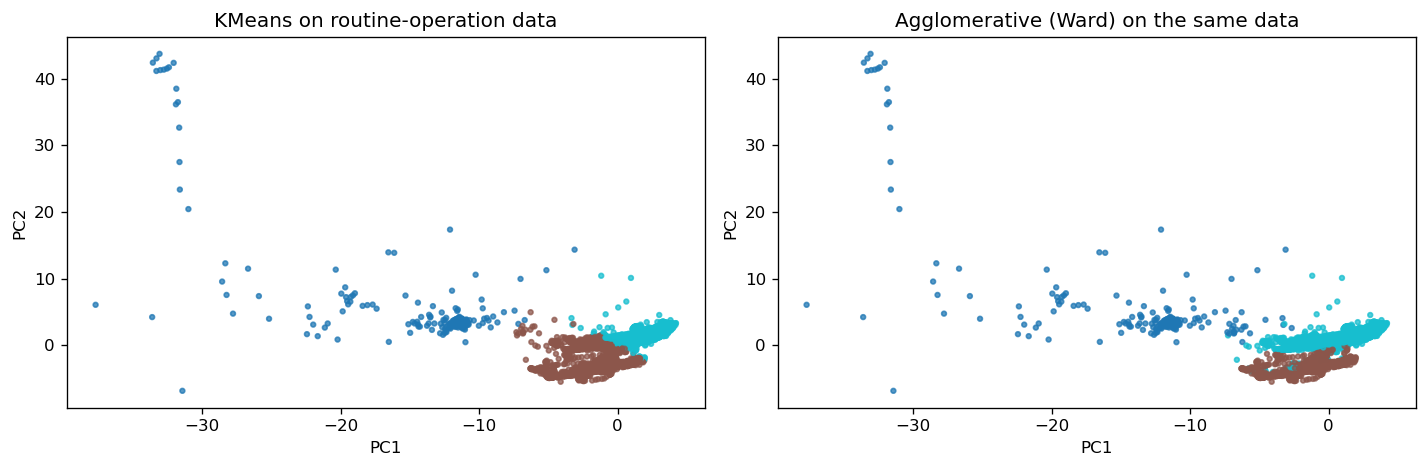

In [10]:
agglomerative = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels_raw = agglomerative.fit_predict(X_routine_pca[:, :n90_routine])
agg_labels, _ = remap_by_impurity(agg_labels_raw, routine['y:Impurity'].to_numpy())

agg_summary = (
    routine.assign(agg_cluster=agg_labels)
    .groupby('agg_cluster')
    .agg(
        count=('y:Impurity', 'size'),
        impurity_mean=('y:Impurity', 'mean'),
        impurity_q90=('y:Impurity', lambda s: s.quantile(0.9)),
        impurity_max=('y:Impurity', 'max'),
    )
)

auto_compare = pd.DataFrame(
    [
        {
            'method': 'KMeans',
            'silhouette': silhouette_score(X_routine_pca[:, :n90_routine], routine_labels),
            'davies_bouldin': davies_bouldin_score(X_routine_pca[:, :n90_routine], routine_labels),
            'cluster_sizes': str([int(x) for x in np.bincount(routine_labels)]),
        },
        {
            'method': 'Agglomerative (Ward)',
            'silhouette': silhouette_score(X_routine_pca[:, :n90_routine], agg_labels),
            'davies_bouldin': davies_bouldin_score(X_routine_pca[:, :n90_routine], agg_labels),
            'cluster_sizes': str([int(x) for x in np.bincount(agg_labels)]),
        },
    ]
)

display(auto_compare.round(3))
display(agg_summary.round(3))
display(pd.crosstab(routine_labels, agg_labels, rownames=['KMeans cluster'], colnames=['Agglomerative cluster']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_routine_pca[:, 0], X_routine_pca[:, 1], c=routine_labels, cmap='tab10', s=8, alpha=0.75)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('KMeans on routine-operation data')

axes[1].scatter(X_routine_pca[:, 0], X_routine_pca[:, 1], c=agg_labels, cmap='tab10', s=8, alpha=0.75)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Agglomerative (Ward) on the same data')
plt.tight_layout()
plt.show()

Ward agglomerative clustering confirms one important part of the `KMeans` story: the short low-throughput transient is still isolated as its own cluster. In the contingency table, essentially all of `KMeans` cluster 0 lands in agglomerative cluster 0.

The difference is in the broader routine modes. Ward clustering gives slightly better silhouette and Davies-Bouldin values on this representation, but it also merges much of the lower- and higher-impurity `KMeans` structure into coarser groups. That is a useful reminder that a “better” clustering metric does not automatically mean a better engineering interpretation.

For this notebook, `KMeans` remains the clearer teaching model because it separates two broad routine operating modes plus one transient regime in a way that is easy to explain from pressures, temperatures, and differential pressures.

(sec-eoa2-hw8)=
### Connection to HW8
HW8 deliberately revisits several ideas from this lecture, but in a more formal monitoring workflow.

What overlaps with this lecture:
- standardizing the sensor variables before clustering,
- PCA as a lower-dimensional representation,
- `KMeans` operating-mode discovery,
- silhouette and Davies-Bouldin as clustering diagnostics,
- post-hoc interpretation using shifted sensor variables and impurity overlays.

What HW8 adds beyond this lecture:
- a train/validation-style data workflow,
- more explicit risk interpretation of the clusters,
- anomaly detection with `IsolationForest`,
- an optional detector-comparison exercise.

So the overlap is intentional. This lecture is the exploratory case study; HW8 is the structured assessment that formalizes the workflow and extends it into unsupervised monitoring.

(sec-eoa2-refs)=
## References
- `StandardScaler` (scikit-learn): https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- `PCA` (scikit-learn): https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- `KMeans` (scikit-learn): https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- `AgglomerativeClustering` (scikit-learn): https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html
- Silhouette score (scikit-learn): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html
- Davies-Bouldin score (scikit-learn): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html